In [27]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

In [28]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    for f in files:
        print("  -", f)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/muhammadzackyrachim
/kaggle/input/datasets/muhammadzackyrachim/modelin
  - train.csv
  - test.csv


In [29]:
train_df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/modelin/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/modelin/test.csv')

print(train_df.shape)
print(test_df.shape)
train_df.head()

(3539, 38)
(885, 38)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,dropout_risk
0,1,1,1,9147,1,1,130.0,1,38,37,...,5,5,1,12.000000,0,7.6,2.6,0.32,Dropout,1
1,1,1,1,9853,1,1,129.0,1,38,37,...,6,10,4,11.500000,0,7.6,2.6,0.32,Dropout,1
2,2,39,1,9991,0,1,140.0,1,37,37,...,5,9,2,11.000000,0,12.7,3.7,-1.70,Dropout,1
3,1,17,2,9670,1,1,129.0,1,19,19,...,6,10,5,13.125000,0,10.8,1.4,1.74,Dropout,1
4,1,1,3,9085,1,1,138.0,1,1,1,...,6,12,6,13.833333,0,8.9,1.4,3.51,Graduate,0


In [30]:
target_col = 'dropout_risk'
drop_cols = ['Target', 'dropout_risk']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

In [31]:
numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

In [32]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    )
}

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    f1_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1')
    roc_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='roc_auc')

    cv_results.append({
        'Model': name,
        'F1 Mean': f1_scores.mean(),
        'F1 Std': f1_scores.std(),
        'ROC-AUC Mean': roc_scores.mean()
    })

cv_df = pd.DataFrame(cv_results).sort_values(by='F1 Mean', ascending=False)
cv_df

,Model,F1 Mean,F1 Std,ROC-AUC Mean
0,Logistic Regression,0.794368,0.021545,0.914768
1,Random Forest,0.790107,0.017608,0.915500


In [34]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8779661016949153
Precision: 0.8410852713178295
Recall   : 0.7640845070422535
F1-score : 0.8007380073800738
ROC-AUC  : 0.9293313960300907

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       601
           1       0.84      0.76      0.80       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



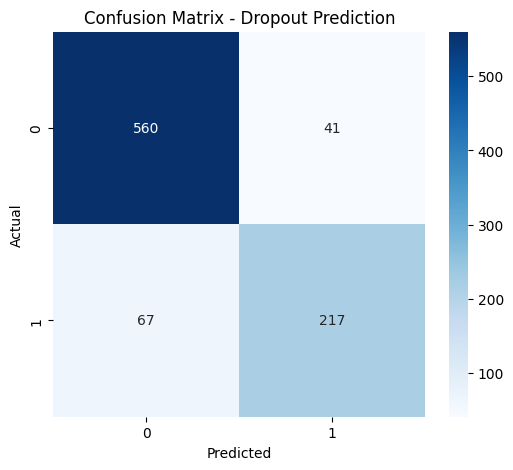

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Dropout Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [36]:
rf_model = best_model.named_steps['model']
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(15)

,feature,importance
30,Curricular units 2nd sem (approved),0.203079
31,Curricular units 2nd sem (grade),0.118919
24,Curricular units 1st sem (approved),0.102691
25,Curricular units 1st sem (grade),0.073666
16,Tuition fees up to date,0.068372
19,Age at enrollment,0.041881
29,Curricular units 2nd sem (evaluations),0.032260
3,Course,0.025856
12,Admission grade,0.025706
6,Previous qualification (grade),0.024988


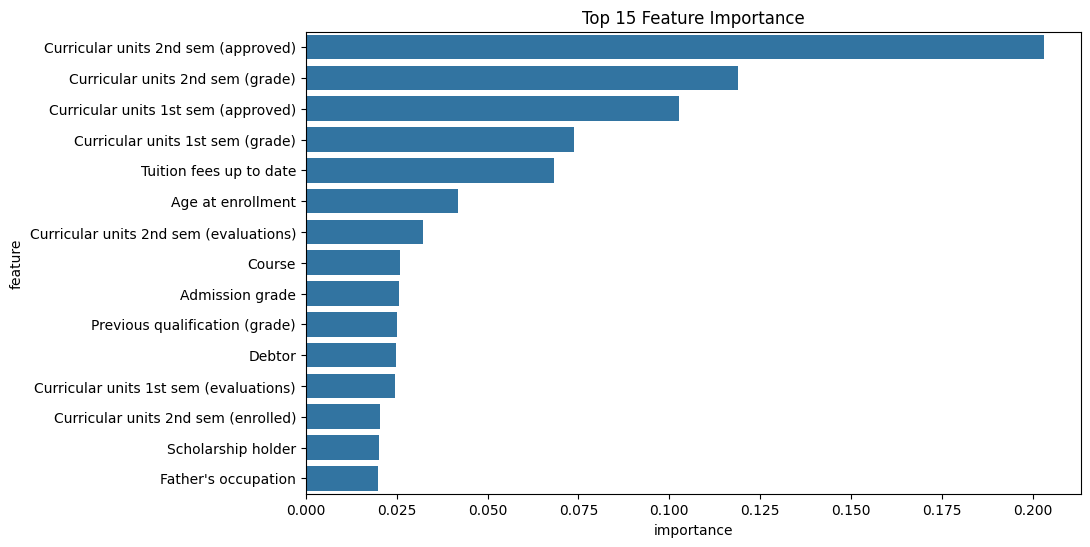

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance')
plt.show()

In [38]:
os.makedirs('/kaggle/working/models', exist_ok=True)
joblib.dump(best_model, '/kaggle/working/models/best_model.pkl')
print("Model saved!")

Model saved!


In [39]:
import os
import json
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [40]:
X_train = train_df.drop(columns=['Target', 'dropout_risk'])
y_train = train_df['dropout_risk']

X_test = test_df.drop(columns=['Target', 'dropout_risk'])
y_test = test_df['dropout_risk']

In [41]:
y_pred = best_model.predict(X_test)

# probabilitas untuk ROC-AUC
if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba = None

In [42]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

if y_proba is not None:
    roc_auc = roc_auc_score(y_test, y_proba)
else:
    roc_auc = None

cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

In [43]:
os.makedirs('/kaggle/working/models', exist_ok=True)

metrics_dict = {
    "model_name": "RandomForest",  # ganti sesuai model terbaikmu
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc) if roc_auc is not None else None,
    "train_shape": list(X_train.shape),
    "test_shape": list(X_test.shape),
    "target_mapping": {
        "0": "Tidak Dropout",
        "1": "Dropout"
    },
    "confusion_matrix": cm.tolist(),
    "classification_report": report
}

with open('/kaggle/working/models/model_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

print("model_metrics.json berhasil disimpan di /kaggle/working/models/")

model_metrics.json berhasil disimpan di /kaggle/working/models/


In [44]:
import os
import json
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================
# 1. Load processed data
# =========================
train_df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/modelin/train.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/modelin/test.csv')

# =========================
# 2. Split feature & target
# =========================
target_col = 'dropout_risk'

drop_cols = [target_col]
if 'Target' in train_df.columns:
    drop_cols.append('Target')

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

# =========================
# 3. Gunakan model terbaik
# =========================
# pastikan variabel best_model sudah ada dari hasil training
# contoh: best_model = rf_model / xgb_model / pipeline terbaik

y_pred = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba = None

# =========================
# 4. Hitung metrics
# =========================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

# =========================
# 5. Nama model otomatis
# =========================
model_name = type(best_model).__name__

# kalau best_model adalah Pipeline, ambil nama estimator terakhir
if hasattr(best_model, "named_steps"):
    step_names = list(best_model.named_steps.keys())
    last_step = step_names[-1]
    model_name = type(best_model.named_steps[last_step]).__name__

# =========================
# 6. Buat dictionary metrics
# =========================
metrics_dict = {
    "model_name": model_name,
    "problem_type": "Binary Classification",
    "dataset_name": "Student Dropout Prediction",
    "target_column": "dropout_risk",
    "target_mapping": {
        "0": "Tidak Dropout",
        "1": "Dropout"
    },
    "train_shape": list(X_train.shape),
    "test_shape": list(X_test.shape),
    "metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc) if roc_auc is not None else None
    },
    "confusion_matrix": cm.tolist(),
    "classification_report": report
}

# =========================
# 7. Simpan ke JSON
# =========================
os.makedirs('/kaggle/working/models', exist_ok=True)

save_path = '/kaggle/working/models/model_metrics.json'
with open(save_path, 'w') as f:
    json.dump(metrics_dict, f, indent=4)

print(f"Berhasil menyimpan model_metrics.json ke: {save_path}")

Berhasil menyimpan model_metrics.json ke: /kaggle/working/models/model_metrics.json


In [45]:
import os
print(os.listdir('/kaggle/working/models'))

['model_metrics.json', 'best_model.pkl']


In [46]:
import os

os.makedirs('/kaggle/working/app/assets', exist_ok=True)
print("Folder app/assets berhasil dibuat")

Folder app/assets berhasil dibuat


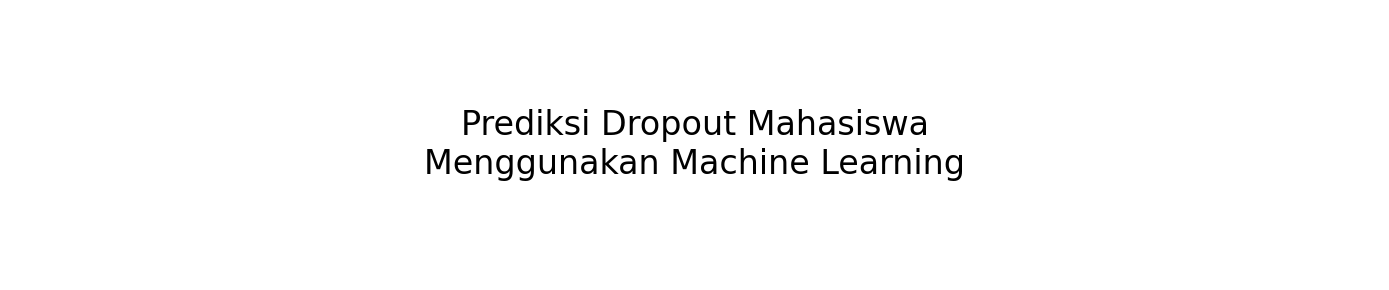

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 3))
plt.text(0.5, 0.5, 'Prediksi Dropout Mahasiswa\nMenggunakan Machine Learning',
         fontsize=24, ha='center', va='center')
plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/app/assets/header.png', dpi=200, bbox_inches='tight')
plt.show()

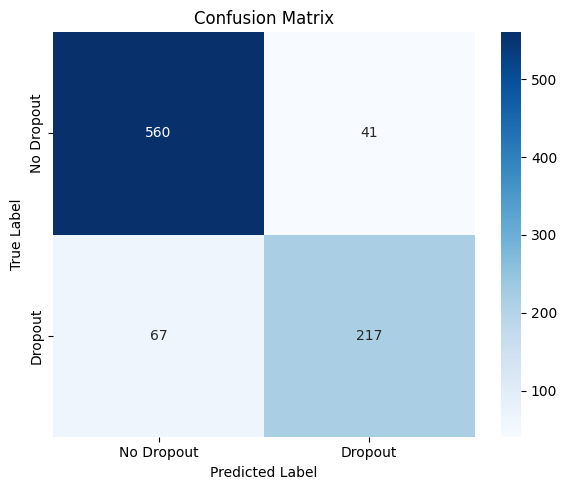

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

os.makedirs('/kaggle/working/app/assets', exist_ok=True)

# prediksi test
y_pred = best_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Dropout', 'Dropout'],
            yticklabels=['No Dropout', 'Dropout'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('/kaggle/working/app/assets/confusion.png', dpi=200)
plt.show()

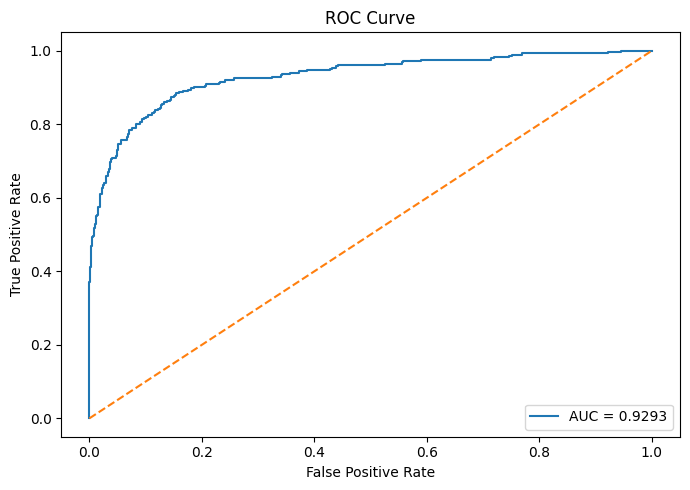

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/kaggle/working/app/assets/roc_curve.png', dpi=200)
plt.show()

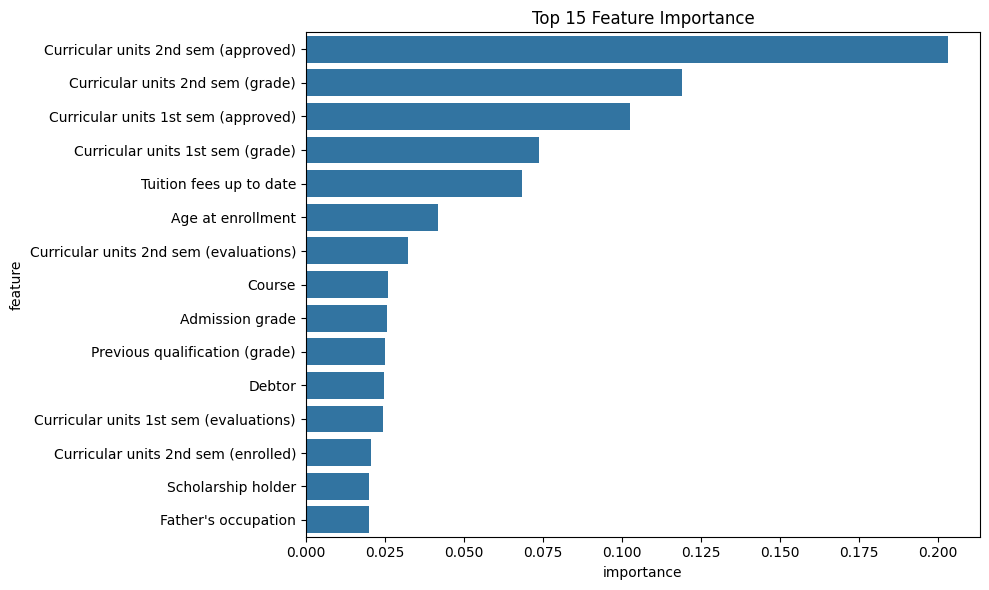

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ambil model random forest dari pipeline
rf_model = best_model.named_steps['model']

# ambil feature importance
importances = rf_model.feature_importances_

# nama fitur dari X_train
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# ambil top 15
top_feat = feat_imp.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_feat, x='importance', y='feature')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.savefig('/kaggle/working/app/assets/feature_importance.png', dpi=200)
plt.show()

In [51]:
import os

print(os.listdir('/kaggle/working/app/assets'))

['confusion.png', 'roc_curve.png', 'feature_importance.png', 'header.png']


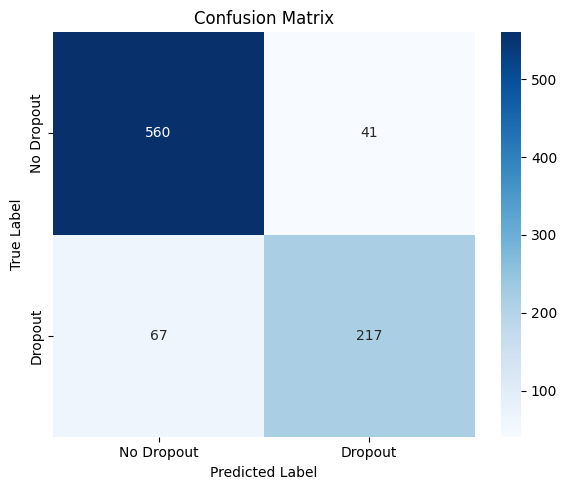

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

os.makedirs('/kaggle/working/figures', exist_ok=True)

# prediksi
y_pred = best_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Dropout', 'Dropout'],
            yticklabels=['No Dropout', 'Dropout'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

plt.savefig('/kaggle/working/figures/confusion_matrix.png', dpi=200)
plt.show()

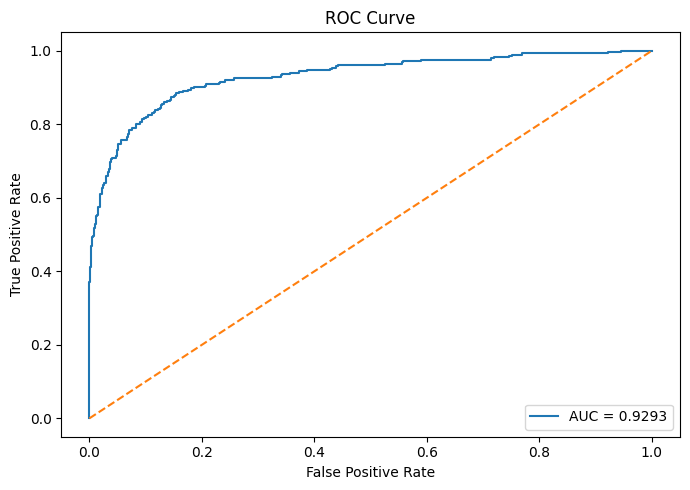

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import os

os.makedirs('/kaggle/working/figures', exist_ok=True)

# probabilitas kelas positif
y_proba = best_model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('/kaggle/working/figures/roc_curve.png', dpi=200)
plt.show()

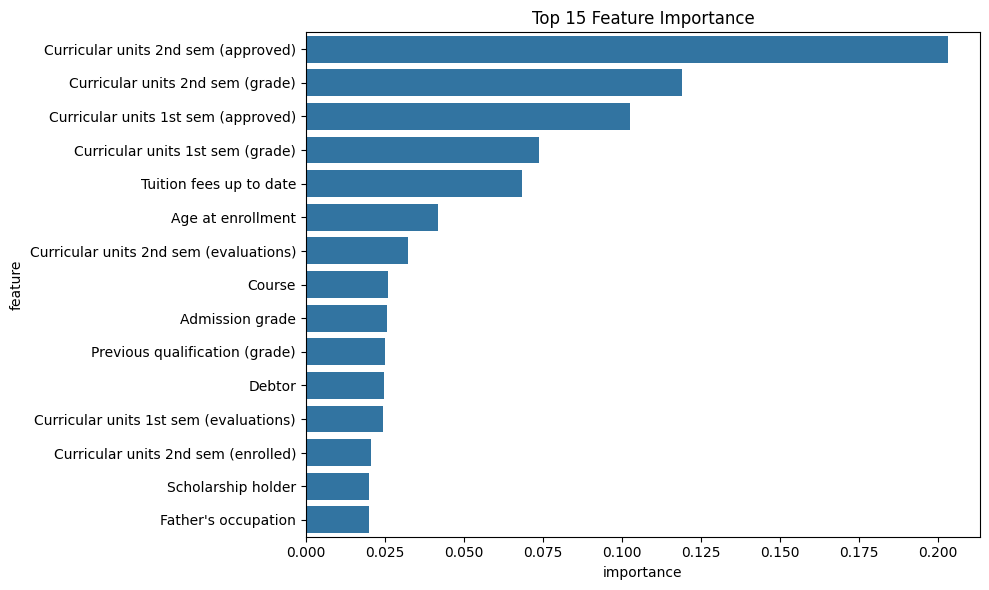

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('/kaggle/working/figures', exist_ok=True)

# ambil model Random Forest dari pipeline
rf_model = best_model.named_steps['model']

# ambil importance
importances = rf_model.feature_importances_

# nama fitur dari X_train
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

top_feat = feat_imp.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_feat, x='importance', y='feature')
plt.title('Top 15 Feature Importance')
plt.tight_layout()

plt.savefig('/kaggle/working/figures/feature_importance.png', dpi=200)
plt.show()